In [75]:
import os, random
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import random_split
from torchvision import transforms
from torchsummary import summary
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle

In [187]:
max_in_class = 200
train_part = 0.5
noise = 0.1
batch_size = 30

epochs = 30
initial_lr = 0.0005

device = "cpu"

In [165]:
class CSVDataset(Dataset):
    def __init__(self, dataframe):
        self.data = dataframe.reset_index(drop=True)
        self.X = self.data.iloc[:, :-1].values
        self.y = self.data.iloc[:, -1].values

        self.X = torch.tensor(self.X, dtype=torch.float32)
        self.y = torch.tensor(self.y, dtype=torch.long)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [205]:
df = pd.read_csv("email_phishing_data.csv")
df = shuffle(df, random_state=42)

df_0 = df[df.iloc[:, -1] == 0].reset_index(drop=True)
df_1 = df[df.iloc[:, -1] == 1].reset_index(drop=True)

train_0 = df_0.iloc[:3000]
train_1 = df_1.iloc[:3000]

train_df = pd.concat([train_0, train_1])
train_df = shuffle(train_df, random_state=42)

remaining_0 = df_0.iloc[3000:]
remaining_1 = df_1.iloc[3000:]

test_1 = remaining_1.iloc[:3000]
needed_0 = 50000 - len(test_1)
test_0 = remaining_0.iloc[:needed_0]

test_df = pd.concat([test_0, test_1])
test_df = shuffle(test_df, random_state=42)

train_dataset = CSVDataset(train_df)
test_dataset = CSVDataset(test_df)

train_dataloader = DataLoader(train_dataset, batch_size= batch_size, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=True)
print(len(train_dataloader.dataset), len(test_dataloader.dataset))

6000 50000


In [207]:
tens_1 = torch.Tensor([[1]]*batch_size)

class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(8, 32)
        self.fc2 = nn.Linear(32, 16)
        self.drop = nn.Dropout(0.05)
        self.fc3 = nn.Linear(16, 2)
        self.drop = nn.Dropout(0.05)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.softmax(self.fc3(x), dim = 1)
        return x

In [209]:
model = SimpleNN()
#summary(model, (1, 28, 28), batch_size, device = device)
print(model)

SimpleNN(
  (fc1): Linear(in_features=8, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=16, bias=True)
  (drop): Dropout(p=0.05, inplace=False)
  (fc3): Linear(in_features=16, out_features=2, bias=True)
)


In [211]:
optimizer = torch.optim.Adam(model.parameters(), lr=initial_lr)
loss_fn = nn.CrossEntropyLoss()

In [213]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.train()
    train_loss, correct = 0, 0
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device).float(), y.to(device)

        # Compute prediction error
        #print(X, data_prep(X))
        pred = model(X)
        loss = loss_fn(pred, y)

        train_loss += loss_fn(pred, y).item()
        correct += (pred.argmax(1) == y).type(torch.float).sum().item()

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    if batch % 100 == 0:
        loss, current = loss.item(), (batch + 1) * len(X)
        print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")
    
    train_loss /= num_batches
    correct /= size

    return correct, train_loss

def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device).float(), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

    return correct, test_loss

In [215]:
history = {
    'train_loss':[],
    'train_accuracy':[],
    'val_loss':[],
    'val_accuracy':[],
    'test_loss':[],
    'test_accuracy':[]
}

for t in range(epochs):
    running_loss = 0.0
    correct = 0
    total = 0
    print(f"Epoch {t+1}\n-------------------------------")
    #if(t % 2 == 0):
    #    initial_lr /= 2
    #    optimizer = torch.optim.Adam(model.parameters(), lr=initial_lr)
    acc, loss = train(train_dataloader, model, loss_fn, optimizer)
    history['train_accuracy'].append(acc)
    history['train_loss'].append(loss)
    acc, loss = test(test_dataloader, model, loss_fn)
    history['val_accuracy'].append(acc)
    history['val_loss'].append(loss)
print("Done!")

Epoch 1
-------------------------------
Test Error: 
 Accuracy: 47.3%, Avg loss: 0.679451 

Epoch 2
-------------------------------
Test Error: 
 Accuracy: 63.6%, Avg loss: 0.638824 

Epoch 3
-------------------------------
Test Error: 
 Accuracy: 58.6%, Avg loss: 0.672722 

Epoch 4
-------------------------------
Test Error: 
 Accuracy: 56.5%, Avg loss: 0.657583 

Epoch 5
-------------------------------
Test Error: 
 Accuracy: 64.8%, Avg loss: 0.637717 

Epoch 6
-------------------------------
Test Error: 
 Accuracy: 70.3%, Avg loss: 0.595482 

Epoch 7
-------------------------------
Test Error: 
 Accuracy: 68.0%, Avg loss: 0.620158 

Epoch 8
-------------------------------
Test Error: 
 Accuracy: 55.5%, Avg loss: 0.702963 

Epoch 9
-------------------------------
Test Error: 
 Accuracy: 72.2%, Avg loss: 0.581126 

Epoch 10
-------------------------------
Test Error: 
 Accuracy: 70.7%, Avg loss: 0.594096 

Epoch 11
-------------------------------
Test Error: 
 Accuracy: 64.9%, Avg los

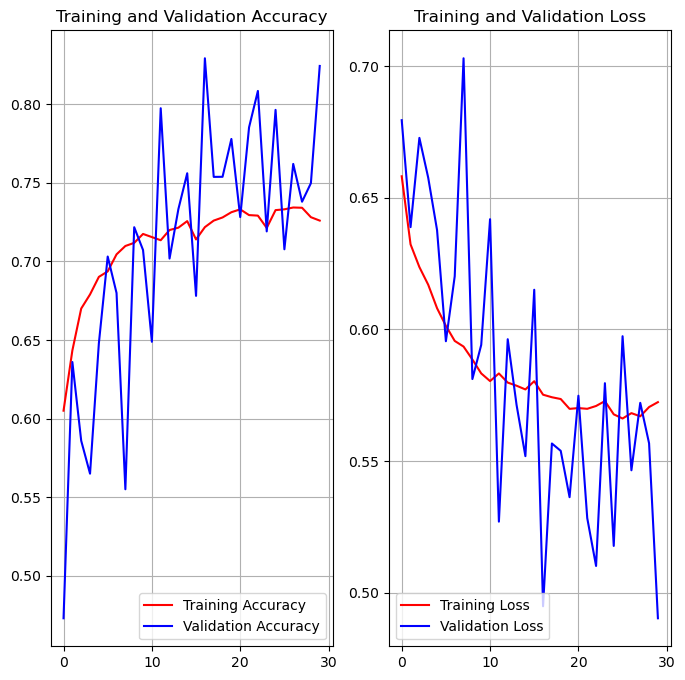

In [217]:
epochs_range = range(epochs)
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_accuracy'], label='Training Accuracy', color='red')
plt.plot(epochs_range, history['val_accuracy'], label='Validation Accuracy', color='blue')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_loss'], label='Training Loss', color='red')
plt.plot(epochs_range, history['val_loss'], label='Validation Loss', color='blue')
plt.legend(loc='lower left')
plt.title('Training and Validation Loss')
plt.grid()
plt.show()

In [219]:
model.eval()
test_dataloader
predictions = torch.LongTensor().to(device)
cmt = torch.zeros(2, 2, dtype=torch.int32)#Матрица ошибок
with torch.no_grad():
    for X, y in test_dataloader:
        X, y = X.to(device).float(), y.to(device)
        preds = model(X.to(device))
        predictions = preds.argmax(dim=1)
        cmt[y, predictions] += 1

In [220]:
pd.set_option('display.max_columns', 2)
pd.DataFrame(cmt.reshape(2, 2))#строка истинное значение, столбец предсказанное

,0,1
0,39542,7458
1,1320,1680
